In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('HR-Employee-Attrition.csv')
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


### Basic checks

In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


In [5]:
df.shape

(1470, 35)

In [6]:
df.sample(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1458,35,No,Travel_Rarely,287,Research & Development,1,4,Life Sciences,1,2052,...,4,80,1,4,5,3,4,3,1,1
1336,55,No,Travel_Rarely,836,Research & Development,2,4,Technical Degree,1,1873,...,2,80,1,19,2,4,5,2,0,4
1145,36,No,Travel_Rarely,559,Research & Development,12,4,Life Sciences,1,1614,...,2,80,2,7,2,3,3,2,1,1
631,44,No,Travel_Rarely,986,Research & Development,8,4,Life Sciences,1,874,...,3,80,1,10,2,2,3,2,0,2
370,21,Yes,Travel_Rarely,156,Sales,12,3,Life Sciences,1,494,...,4,80,0,1,0,3,1,0,0,0
707,47,No,Travel_Frequently,1379,Research & Development,16,4,Medical,1,987,...,3,80,0,20,3,4,19,10,2,7
760,53,No,Travel_Frequently,124,Sales,2,3,Marketing,1,1050,...,1,80,1,30,2,3,15,7,6,12
1343,29,No,Travel_Rarely,592,Research & Development,7,3,Life Sciences,1,1883,...,2,80,0,11,2,3,3,2,1,2
782,30,No,Travel_Rarely,1176,Research & Development,20,3,Other,1,1084,...,3,80,1,7,1,2,6,2,0,2
1368,34,No,Travel_Frequently,735,Research & Development,22,4,Other,1,1932,...,2,80,0,16,3,3,15,10,6,11


In [7]:
pd.set_option('display.max_columns',None)


In [8]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [10]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [11]:
df.describe(include='O')

C:\Users\ugale\AppData\Local\Temp\ipykernel_27640\2537740217.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='O')


,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


In [12]:
df.head(2)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7


In [13]:
df = df.rename(columns={
    "BusinessTravel": "Business_Travel",
    "DailyRate": "Daily_Rate",
    "DistanceFromHome": "Distance_From_Home",
    "EducationField": "Education_Field",
    "EmployeeCount": "Employee_Count",
    "EmployeeNumber": "Employee_Number",
    "EnvironmentSatisfaction": "Environment_Satisfaction",
    "HourlyRate": "Hourly_Rate",
    "JobInvolvement": "Job_Involvement",
    "JobLevel": "Job_Level",
    "JobRole": "Job_Role",
    "JobSatisfaction": "Job_Satisfaction",
    "MaritalStatus": "Marital_Status",
    "MonthlyIncome": "Monthly_Income",
    "MonthlyRate": "Monthly_Rate",
    "NumCompaniesWorked": "Num_Companies_Worked",
    "OverTime": "Over_Time",
    "PercentSalaryHike": "Percent_Salary_Hike",
    "PerformanceRating": "Performance_Rating",
    "RelationshipSatisfaction": "Relationship_Satisfaction",
    "StandardHours": "Standard_Hours",
    "StockOptionLevel": "Stock_Option_Level",
    "TotalWorkingYears": "Total_Working_Years",
    "TrainingTimesLastYear": "Training_Times_Last_Year",
    "WorkLifeBalance": "Work_Life_Balance",
    "YearsAtCompany": "Years_At_Company",
    "YearsInCurrentRole": "Years_In_Current_Role",
    "YearsSinceLastPromotion": "Years_Since_Last_Promotion",
    "YearsWithCurrManager": "Years_With_Current_Manager"
})

In [14]:
df.head()

,Age,Attrition,Business_Travel,Daily_Rate,Department,Distance_From_Home,Education,Education_Field,Employee_Count,Employee_Number,Environment_Satisfaction,Gender,Hourly_Rate,Job_Involvement,Job_Level,Job_Role,Job_Satisfaction,Marital_Status,Monthly_Income,Monthly_Rate,Num_Companies_Worked,Over18,Over_Time,Percent_Salary_Hike,Performance_Rating,Relationship_Satisfaction,Standard_Hours,Stock_Option_Level,Total_Working_Years,Training_Times_Last_Year,Work_Life_Balance,Years_At_Company,Years_In_Current_Role,Years_Since_Last_Promotion,Years_With_Current_Manager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [15]:
df.columns = df.columns.str.lower()

In [16]:
df.head()

,age,attrition,business_travel,daily_rate,department,distance_from_home,education,education_field,employee_count,employee_number,environment_satisfaction,gender,hourly_rate,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,monthly_rate,num_companies_worked,over18,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,standard_hours,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_current_manager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [17]:
for i in df:
    print(i)

age
attrition
business_travel
daily_rate
department
distance_from_home
education
education_field
employee_count
employee_number
environment_satisfaction
gender
hourly_rate
job_involvement
job_level
job_role
job_satisfaction
marital_status
monthly_income
monthly_rate
num_companies_worked
over18
over_time
percent_salary_hike
performance_rating
relationship_satisfaction
standard_hours
stock_option_level
total_working_years
training_times_last_year
work_life_balance
years_at_company
years_in_current_role
years_since_last_promotion
years_with_current_manager


In [18]:
print(df.business_travel.unique())
df.business_travel.value_counts()

<ArrowStringArray>
['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Length: 3, dtype: str


business_travel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

In [19]:
df.business_travel.unique()

<ArrowStringArray>
['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Length: 3, dtype: str

In [20]:
df.education_field.value_counts()

education_field
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

In [21]:
df.job_role.value_counts()

job_role
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

In [22]:
for i in df:
    if len(df[i].unique()) <= 10:
        print(i,':',df[i].unique())
        print('='*60)

attrition : <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
business_travel : <ArrowStringArray>
['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Length: 3, dtype: str
department : <ArrowStringArray>
['Sales', 'Research & Development', 'Human Resources']
Length: 3, dtype: str
education : [2 1 4 3 5]
education_field : <ArrowStringArray>
[   'Life Sciences',            'Other',          'Medical',
        'Marketing', 'Technical Degree',  'Human Resources']
Length: 6, dtype: str
employee_count : [1]
environment_satisfaction : [2 3 4 1]
gender : <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
job_involvement : [3 2 4 1]
job_level : [2 1 3 4 5]
job_role : <ArrowStringArray>
[          'Sales Executive',        'Research Scientist',
     'Laboratory Technician',    'Manufacturing Director',
 'Healthcare Representative',                   'Manager',
      'Sales Representative',         'Research Director',
           'Human Resources']
Length: 9, dtype: str
job_satisf

In [23]:
for i in df:
    if len(df[i].unique()) <= 10:
        print(i,':',df[i].value_counts())
        print("="*30)



attrition : attrition
No     1233
Yes     237
Name: count, dtype: int64
business_travel : business_travel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64
department : department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64
education : education
3    572
4    398
2    282
1    170
5     48
Name: count, dtype: int64
education_field : education_field
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64
employee_count : employee_count
1    1470
Name: count, dtype: int64
environment_satisfaction : environment_satisfaction
3    453
4    446
2    287
1    284
Name: count, dtype: int64
gender : gender
Male      882
Female    588
Name: count, dtype: int64
job_involvement : job_involvement
3    868
2    375
4    144
1     83
Name: count, dtype: int64
job_l

In [24]:
# continuous column data
# -------------------------------------------
# Age,
#  DailyRate, 
#  DistanceFromHome, 
#  HourlyRate,
#   MonthlyIncome,
#    MonthlyRate, 
#    NumCompaniesWorked,
#     PercentSalaryHike, 
#     TotalWorkingYears,
#      TrainingTimesLastYear,
#       YearsAtCompany,
#        YearsInCurrentRole,
#         YearsSinceLastPromotion,
#          YearsWithCurrManager


In [25]:
# categorical
# -------------------------------------------
# Attrition,      1
#  BusinessTravel, 1
#  Department,   1
# Education, 1
#   EducationField,  1
#    Gender,         1
#     JobRole, 1
#      MaritalStatus,1
#       OverTime, 1
#        EnvironmentSatisfaction, 1
#         JobInvolvement,  1
#         JobLevel, 1
#         JobSatisfaction,  1
#          PerformanceRating, 1
#           RelationshipSatisfaction,  1
#           StockOptionLevel, 
#           WorkLifeBalance

### EDA

#### Univariate analysis

In [26]:
df.sample(5)

,age,attrition,business_travel,daily_rate,department,distance_from_home,education,education_field,employee_count,employee_number,environment_satisfaction,gender,hourly_rate,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,monthly_rate,num_companies_worked,over18,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,standard_hours,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_current_manager
941,30,No,Travel_Rarely,1138,Research & Development,6,3,Technical Degree,1,1311,1,Female,48,2,2,Laboratory Technician,4,Married,4627,23631,0,Y,No,12,3,1,80,1,10,6,3,9,2,6,7
521,27,No,Travel_Frequently,1410,Sales,3,1,Medical,1,714,4,Female,71,4,2,Sales Executive,4,Divorced,4647,16673,1,Y,Yes,20,4,2,80,2,6,3,3,6,5,0,4
506,37,No,Travel_Rarely,482,Research & Development,3,3,Other,1,689,3,Male,36,3,3,Manufacturing Director,3,Married,9434,9606,1,Y,No,15,3,3,80,1,10,2,3,10,7,7,8
1454,45,No,Travel_Rarely,374,Sales,20,3,Life Sciences,1,2046,4,Female,50,3,2,Sales Executive,3,Single,4850,23333,8,Y,No,15,3,3,80,0,8,3,3,5,3,0,1
970,27,No,Travel_Rarely,1291,Sales,11,3,Medical,1,1364,3,Female,98,4,1,Sales Representative,4,Married,2534,6527,8,Y,No,14,3,2,80,1,5,4,3,1,0,0,0


#### drop cols

In [27]:
# df.drop(columns={'employee_count','employee_number','over18','standard_hours'},inplace=True)

In [28]:
len(df.columns)

35

In [29]:
df.head(2)

,age,attrition,business_travel,daily_rate,department,distance_from_home,education,education_field,employee_count,employee_number,environment_satisfaction,gender,hourly_rate,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,monthly_rate,num_companies_worked,over18,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,standard_hours,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_current_manager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7


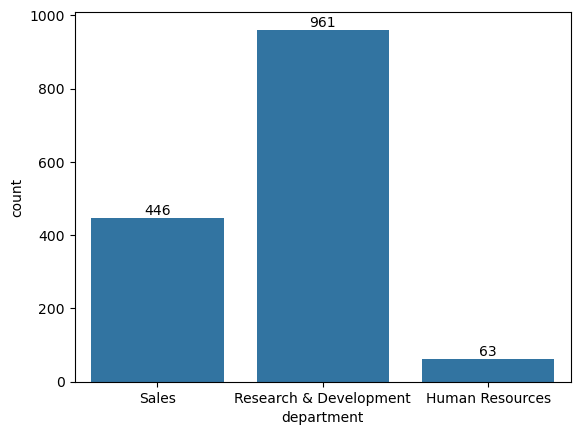

In [30]:
ax = sns.countplot(x=df.department)

ax.bar_label(ax.containers[0])

plt.show()

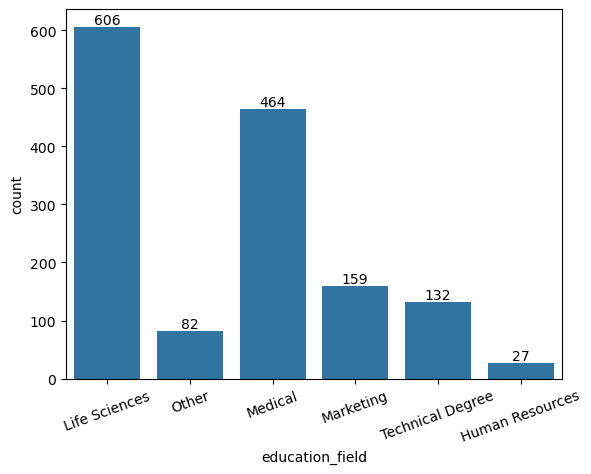

In [31]:
ax = sns.countplot(x=df.education_field)

ax.bar_label(ax.containers[0])
plt.xticks(rotation = 20)
plt.show()

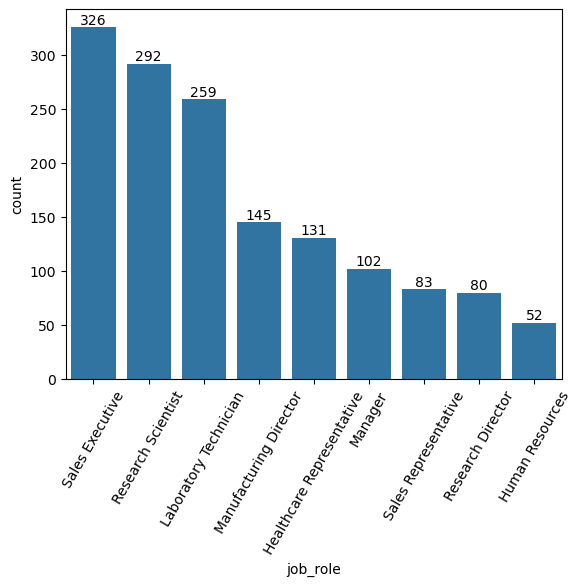

In [32]:
	
ax = sns.countplot(x=df.job_role)

ax.bar_label(ax.containers[0])
plt.xticks(rotation = 60)
plt.show()

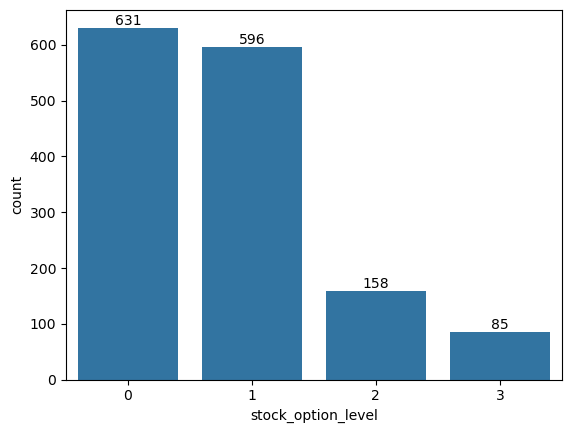

In [33]:
ax = sns.countplot(x=df.stock_option_level)

ax.bar_label(ax.containers[0])
plt.show()

In [34]:
len(df.columns)

35

In [35]:
categorical = ["attrition", "business_travel", "department", "education_field",
    "gender", "job_role", "marital_status", "over_time",
    "education", "environment_satisfaction", "job_involvement", "job_level",
    "job_satisfaction", "performance_rating", "relationship_satisfaction",
    "stock_option_level", "work_life_balance"]
categorical
print(len(categorical))

17


In [36]:
continuous = ["age", "daily_rate", "distance_from_home", "hourly_rate", "monthly_income",
    "monthly_rate", "num_companies_worked", "percent_salary_hike",
    "total_working_years", "training_times_last_year", "years_at_company",
    "years_in_current_role", "years_since_last_promotion", "years_with_current_manager"]
continuous
print(len(continuous))

14


In [37]:
df_cont = df[continuous]
df_cont.head()

,age,daily_rate,distance_from_home,hourly_rate,monthly_income,monthly_rate,num_companies_worked,percent_salary_hike,total_working_years,training_times_last_year,years_at_company,years_in_current_role,years_since_last_promotion,years_with_current_manager
0,41,1102,1,94,5993,19479,8,11,8,0,6,4,0,5
1,49,279,8,61,5130,24907,1,23,10,3,10,7,1,7
2,37,1373,2,92,2090,2396,6,15,7,3,0,0,0,0
3,33,1392,3,56,2909,23159,1,11,8,3,8,7,3,0
4,27,591,2,40,3468,16632,9,12,6,3,2,2,2,2


In [38]:
df_cat = df[categorical]
df_cat.head()

,attrition,business_travel,department,education_field,gender,job_role,marital_status,over_time,education,environment_satisfaction,job_involvement,job_level,job_satisfaction,performance_rating,relationship_satisfaction,stock_option_level,work_life_balance
0,Yes,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Yes,2,2,3,2,4,3,1,0,1
1,No,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married,No,1,3,2,2,2,4,4,1,3
2,Yes,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single,Yes,2,4,2,1,3,3,2,0,3
3,No,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married,Yes,4,4,3,1,3,3,3,0,3
4,No,Travel_Rarely,Research & Development,Medical,Male,Laboratory Technician,Married,No,1,1,3,1,2,3,4,1,3


In [39]:
for i in df_cat:
    print(i)

attrition
business_travel
department
education_field
gender
job_role
marital_status
over_time
education
environment_satisfaction
job_involvement
job_level
job_satisfaction
performance_rating
relationship_satisfaction
stock_option_level
work_life_balance


In [40]:
for i in df_cont:
    print(i)

age
daily_rate
distance_from_home
hourly_rate
monthly_income
monthly_rate
num_companies_worked
percent_salary_hike
total_working_years
training_times_last_year
years_at_company
years_in_current_role
years_since_last_promotion
years_with_current_manager


In [41]:
print('cat :',len(df_cat.columns))
print('num :',len(df_cont.columns))

cat : 17
num : 14


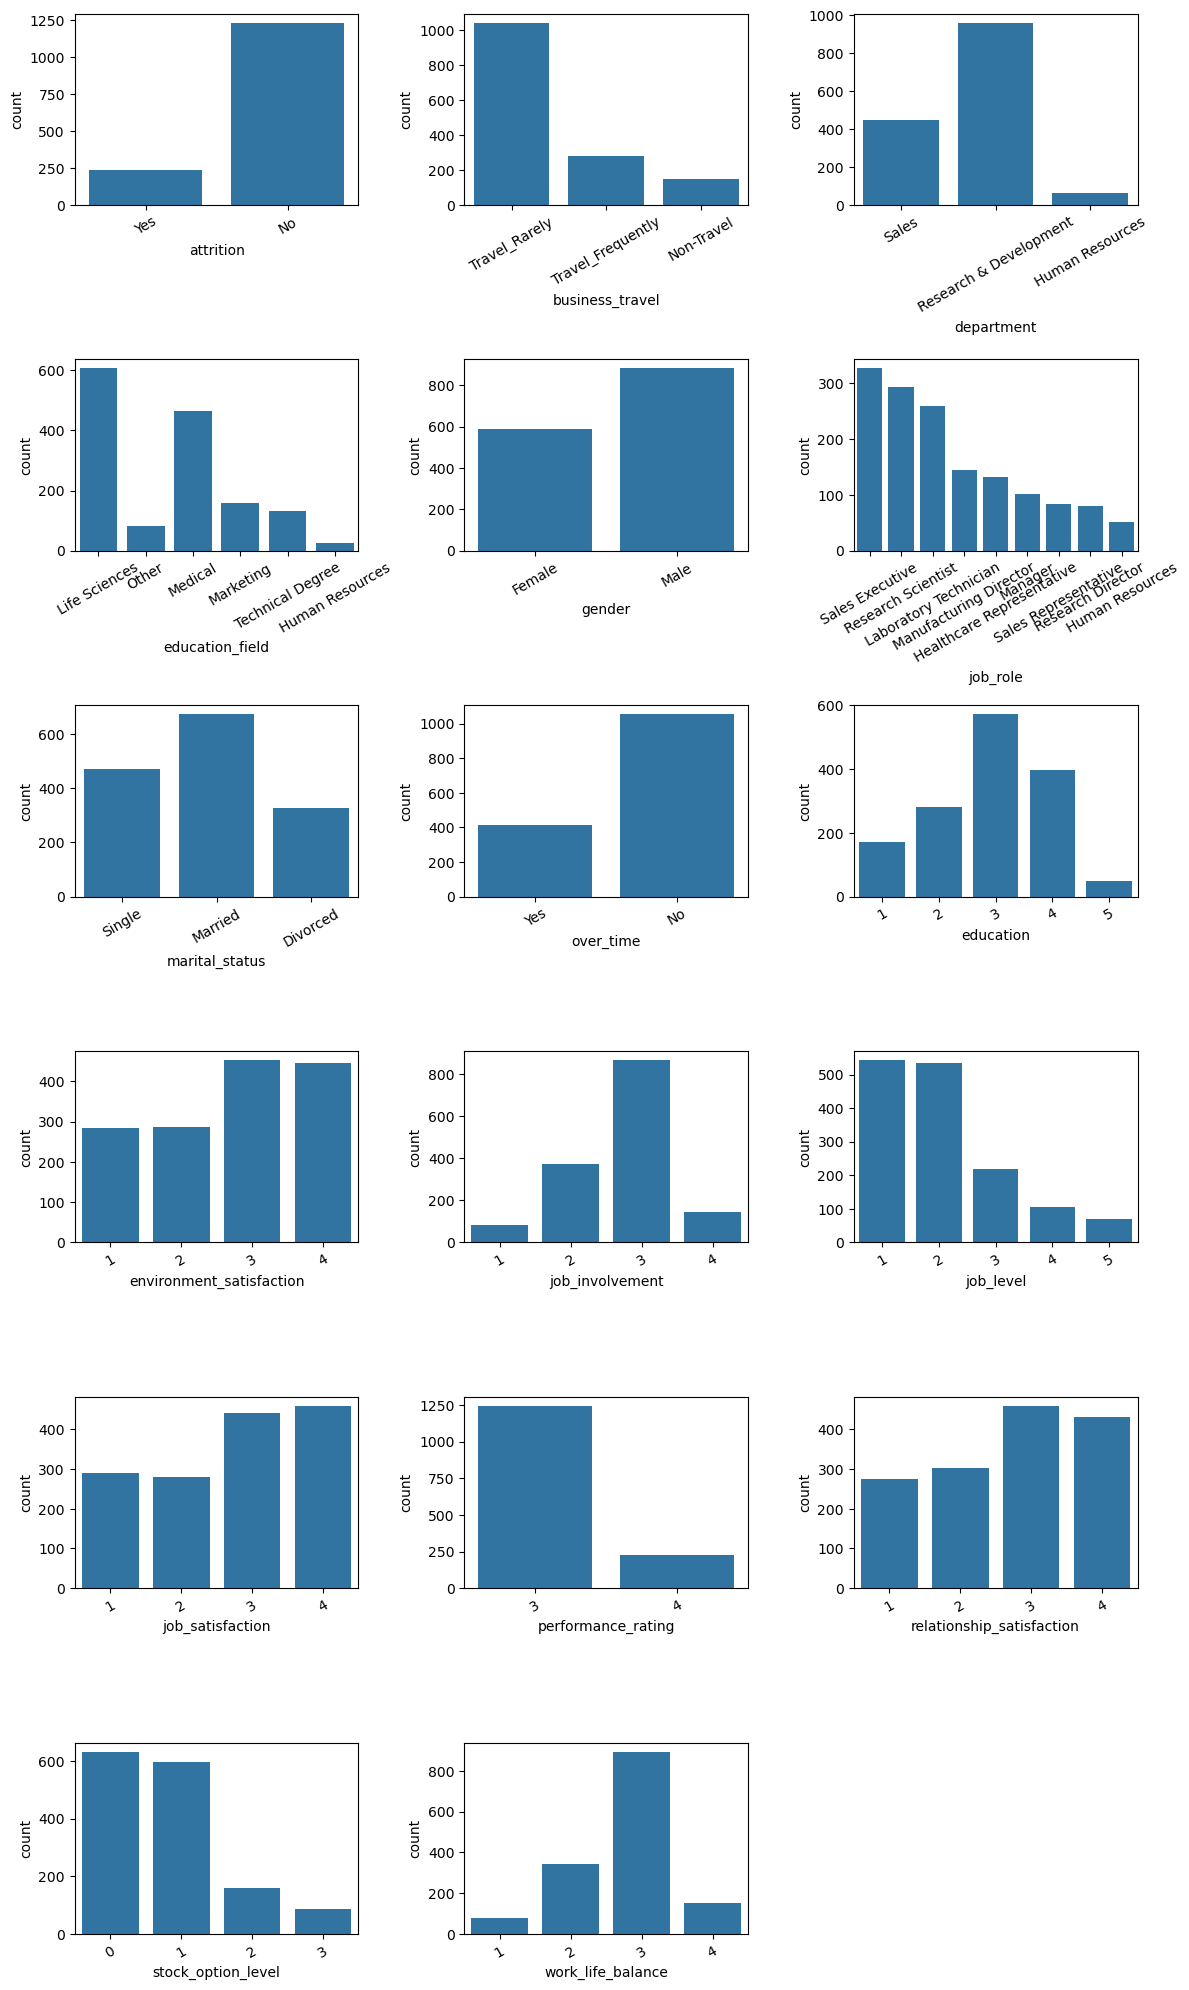

In [42]:
plotnumber = 1

plt.figure(figsize=(12,20))
for i in df_cat:
    plt.subplot(6, 3, plotnumber)
    sns.countplot(x = df_cat[i])
    plt.xticks(rotation = 30)
    plotnumber = plotnumber+1
plt.tight_layout()

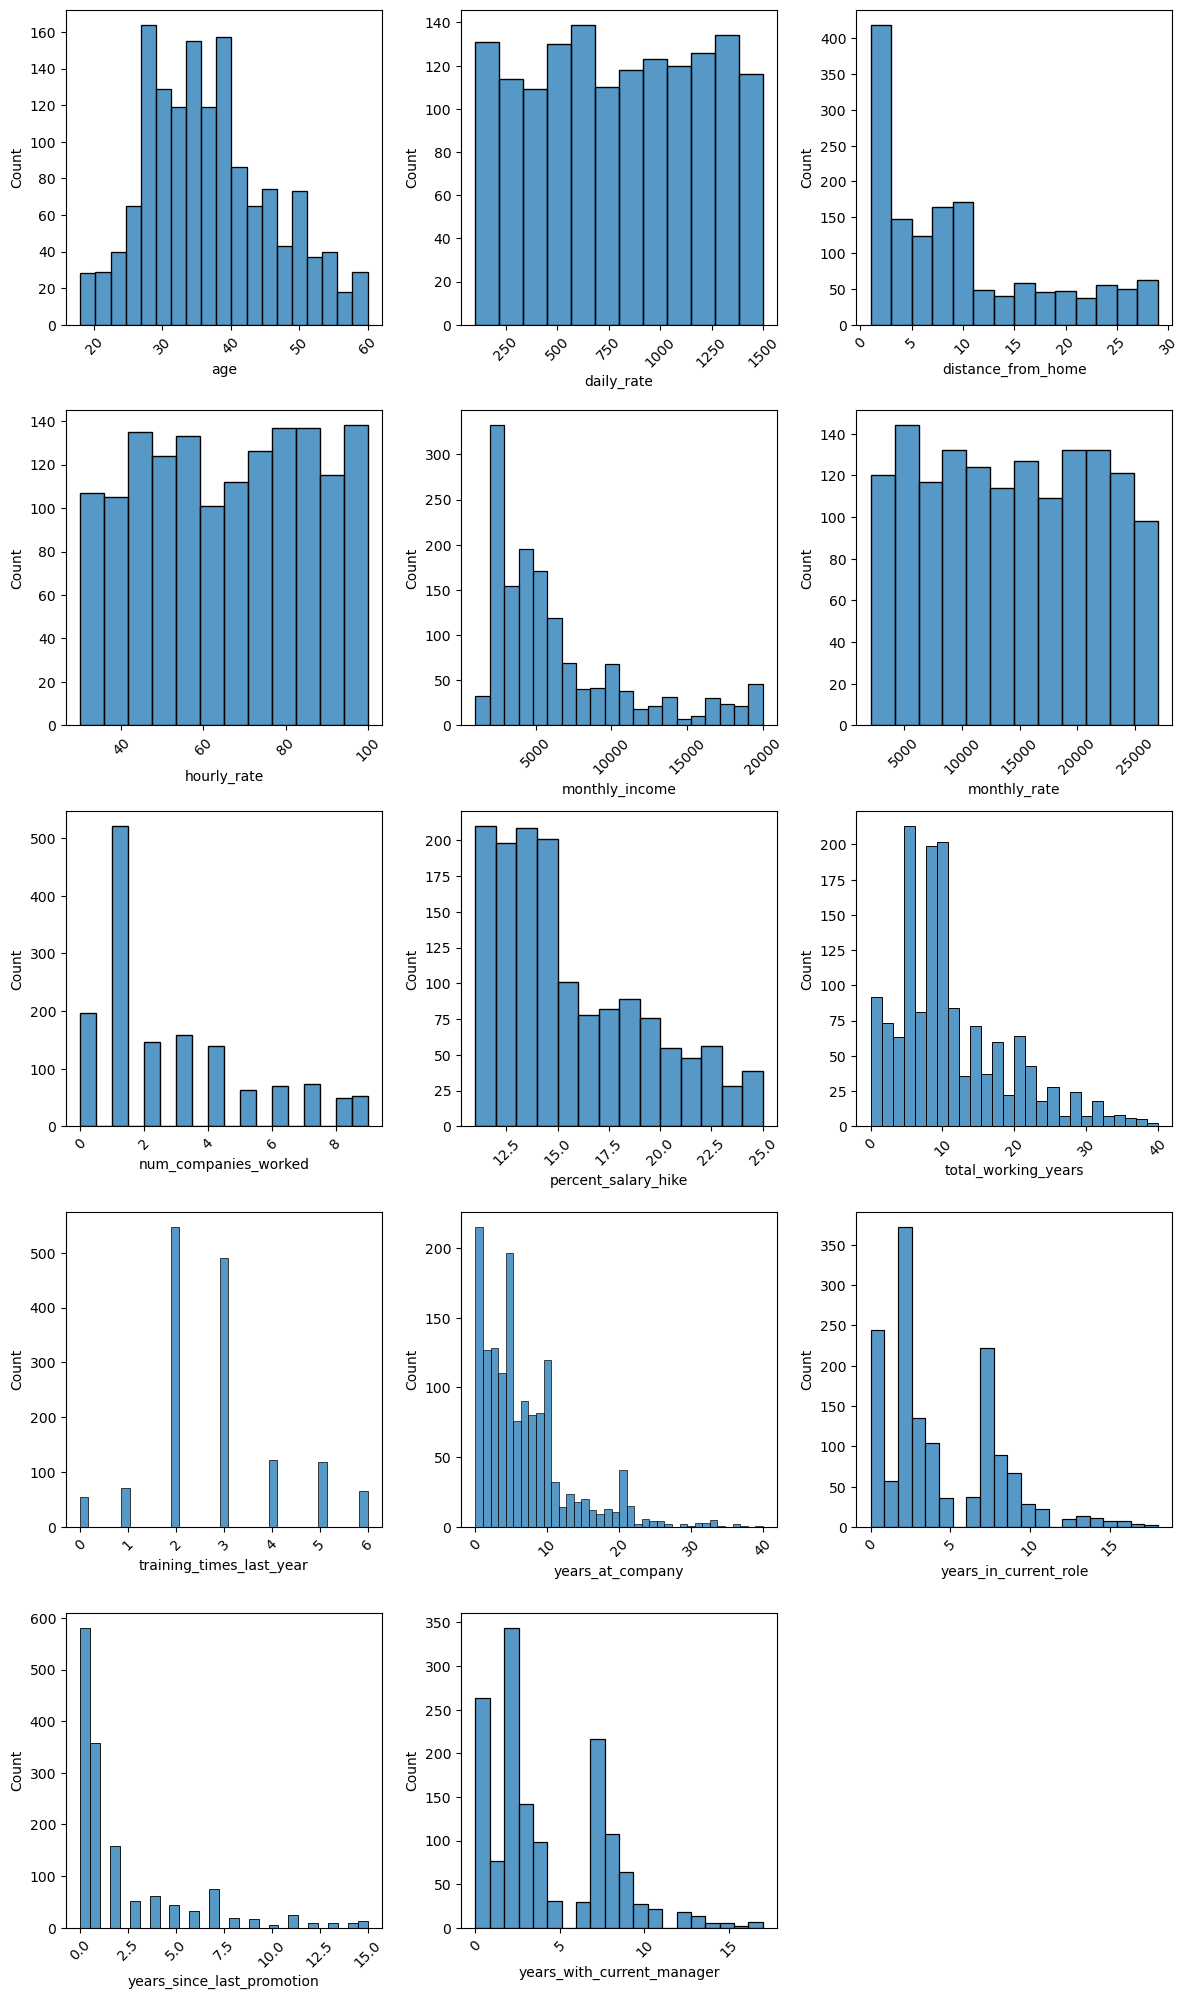

In [43]:
plotnumber = 1

plt.figure(figsize=(12,20))
for i in df_cont:
    plt.subplot(5, 3, plotnumber)
    sns.histplot(x = df_cont[i])
    plt.xticks(rotation = 45)
    plotnumber = plotnumber+1
plt.tight_layout()

#### bivarient analysis

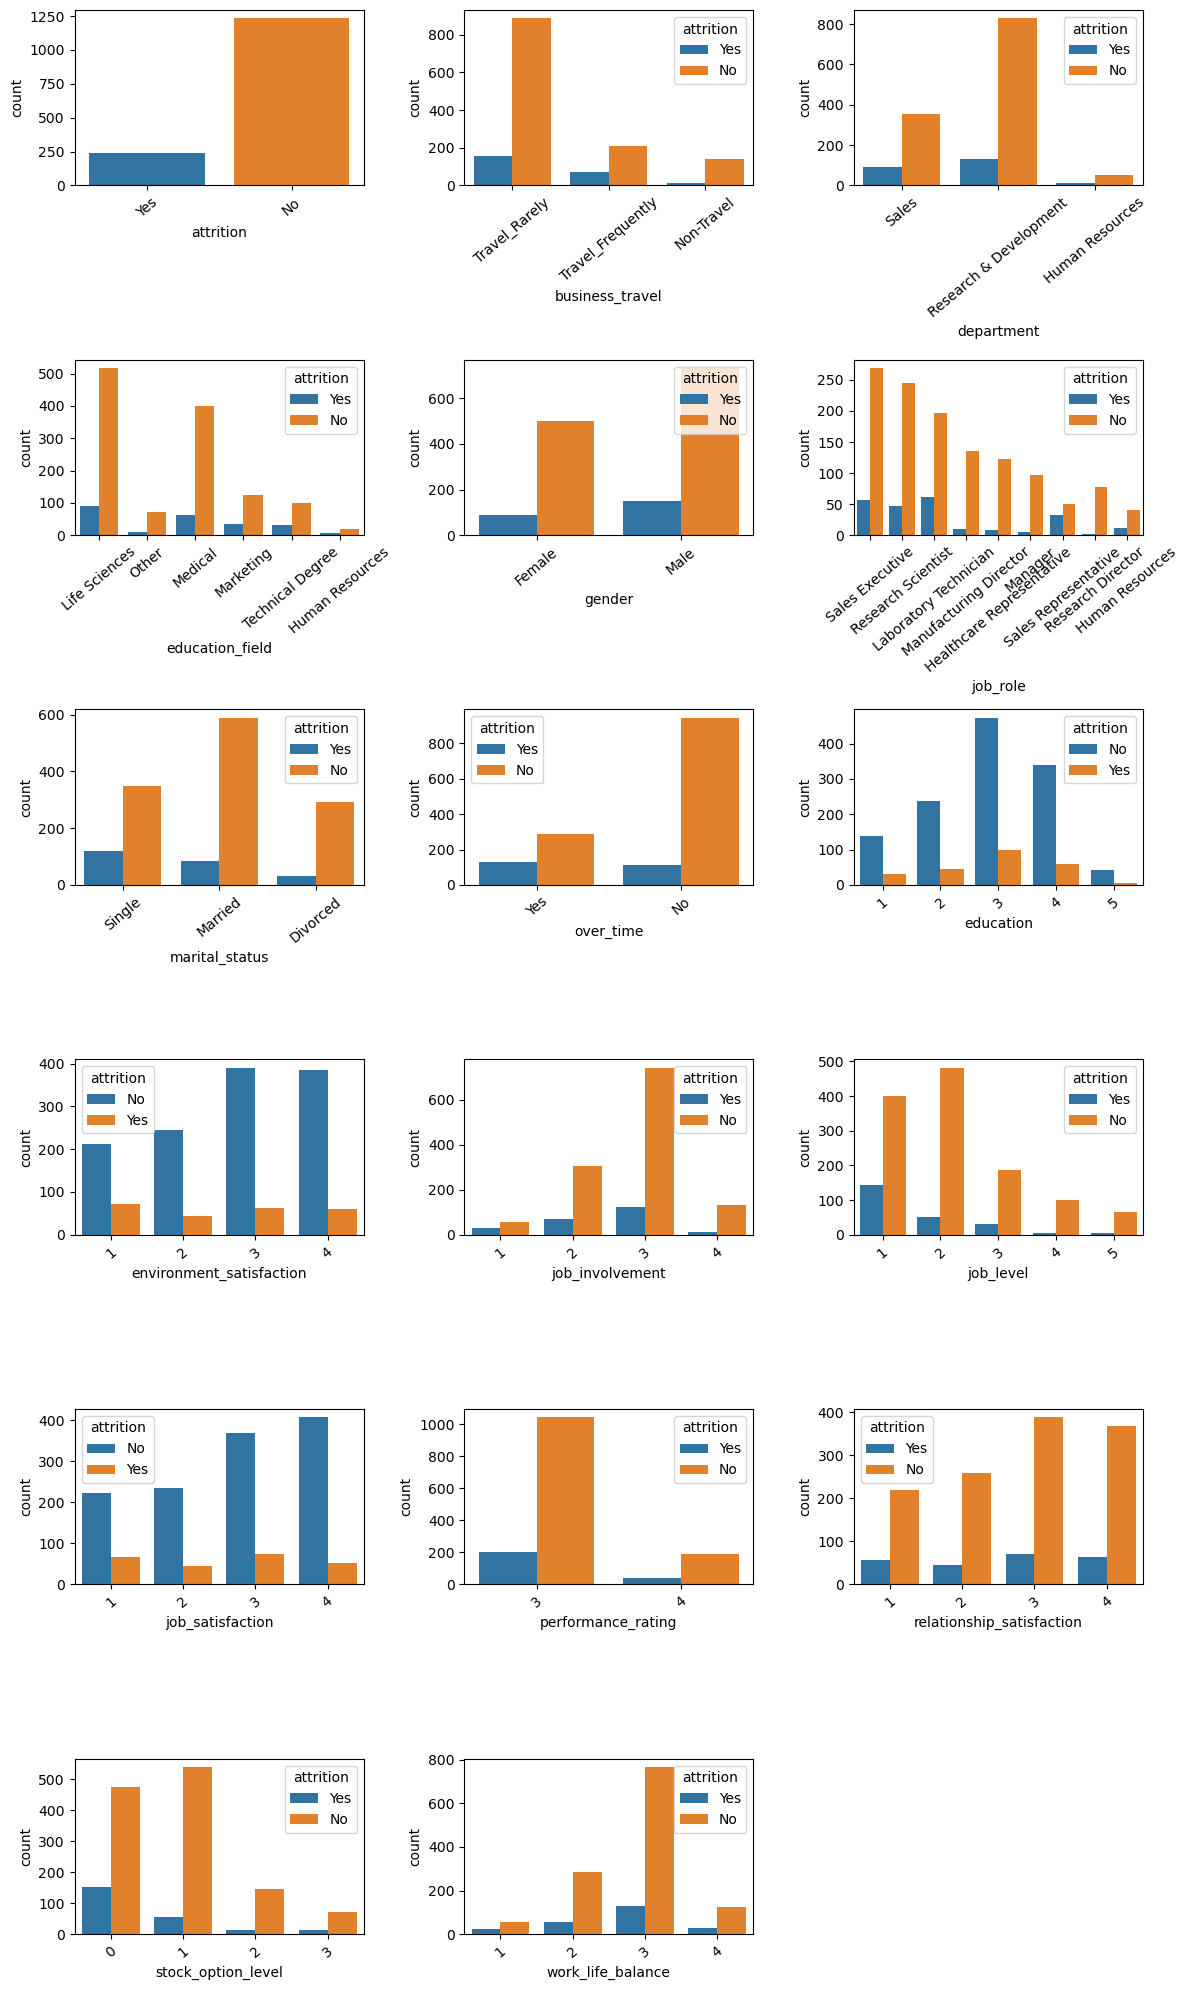

In [44]:
plotnumber = 1

plt.figure(figsize=(12,20))
for i in df_cat:
    plt.subplot(6, 3, plotnumber)
    sns.countplot(x = df_cat[i],hue=df.attrition)
    plt.xticks(rotation = 40)
    plotnumber = plotnumber+1
plt.tight_layout()

##### insights


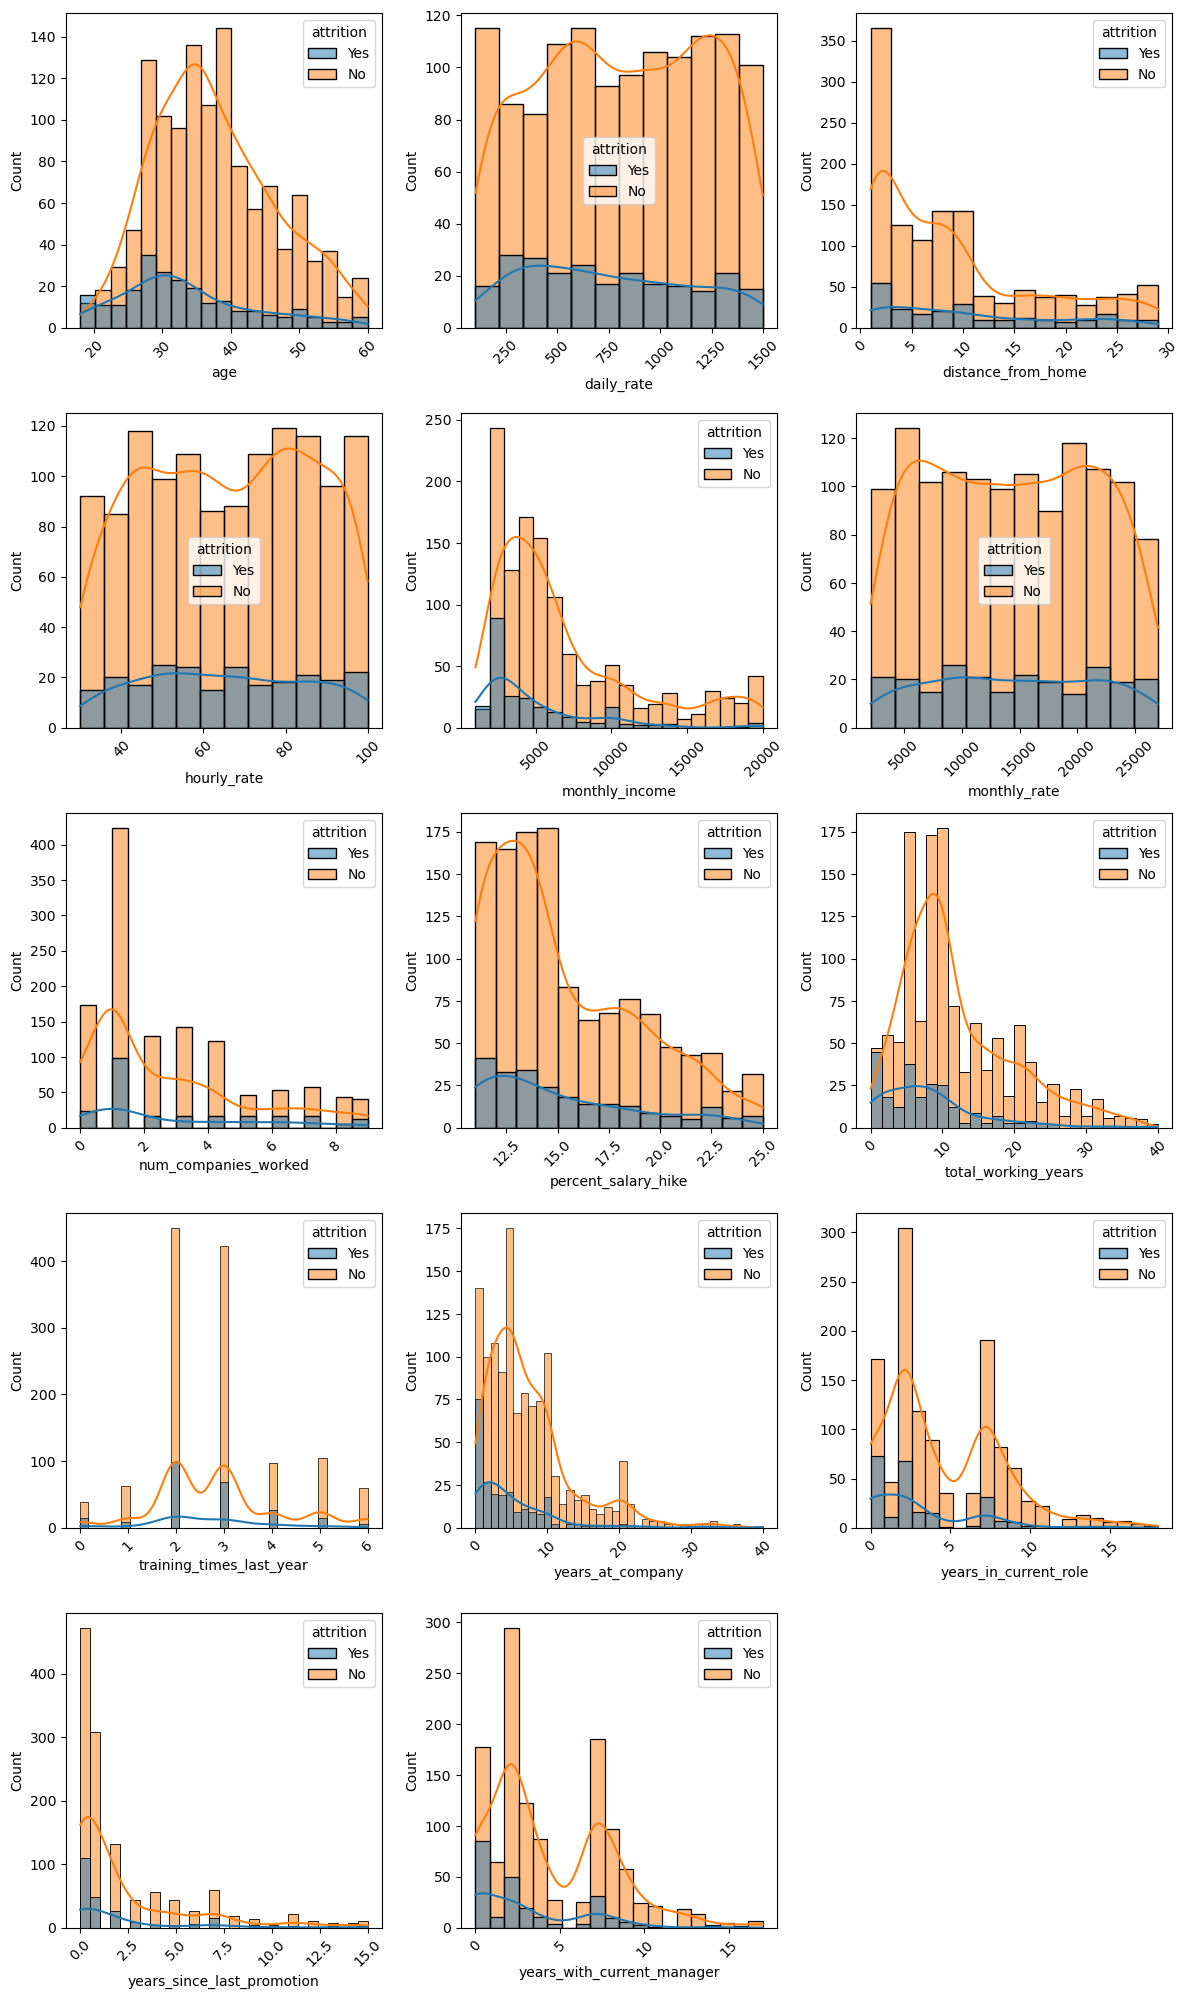

In [45]:
plotnumber = 1

plt.figure(figsize=(12,20))
for i in df_cont:
    plt.subplot(5, 3, plotnumber)
    sns.histplot(x = df_cont[i],hue=df.attrition,kde=True)
    plt.xticks(rotation = 45)
    plotnumber = plotnumber+1
plt.tight_layout()





In [46]:
df.head()

,age,attrition,business_travel,daily_rate,department,distance_from_home,education,education_field,employee_count,employee_number,environment_satisfaction,gender,hourly_rate,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,monthly_rate,num_companies_worked,over18,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,standard_hours,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_current_manager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [47]:
df.shape

(1470, 35)

In [48]:
for i in df:
    print(i)

age
attrition
business_travel
daily_rate
department
distance_from_home
education
education_field
employee_count
employee_number
environment_satisfaction
gender
hourly_rate
job_involvement
job_level
job_role
job_satisfaction
marital_status
monthly_income
monthly_rate
num_companies_worked
over18
over_time
percent_salary_hike
performance_rating
relationship_satisfaction
standard_hours
stock_option_level
total_working_years
training_times_last_year
work_life_balance
years_at_company
years_in_current_role
years_since_last_promotion
years_with_current_manager


In [49]:
df = df.rename(columns = {"over18":"over_18"})

In [50]:
df.shape

(1470, 35)

In [51]:
df.loc[0:,['attrition','over_18','employee_count','standard_hours','employee_number']]


,attrition,over_18,employee_count,standard_hours,employee_number
0,Yes,Y,1,80,1
1,No,Y,1,80,2
2,Yes,Y,1,80,4
3,No,Y,1,80,5
4,No,Y,1,80,7
...,...,...,...,...,...
1465,No,Y,1,80,2061
1466,No,Y,1,80,2062
1467,No,Y,1,80,2064
1468,No,Y,1,80,2065


In [52]:
df.to_csv('hr_employee_attrition_clean.csv',index=False)
print('download done !')

download done !
